# Iris Flower Classification

## Introduction

This project builds a multi-class classification system to predict the species of an iris flower: Setosa, Versicolor, or Virginica.

The prediction is based on four physical measurements:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In this project, three classical machine learning algorithms will be trained and compared on the same dataset to determine which model performs best.

In [1]:
# Imports & Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import sklearn

np.random.seed(42)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

NumPy version: 2.0.2
Pandas version: 2.3.3
Scikit-learn version: 1.6.1


In [2]:
# Load Data

df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 10 Rows:")
display(df.head(10))

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(150, 6)

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

First 10 Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa



Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## Exploratory Data Analysis (EDA)

In this section, we will explore the Iris dataset to understand its structure, class distribution, and the relationships between the flower features. We will use statistical summaries and visualizations to identify which features help distinguish the three Iris species. This analysis will help us understand the data before training and comparing machine learning models.

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


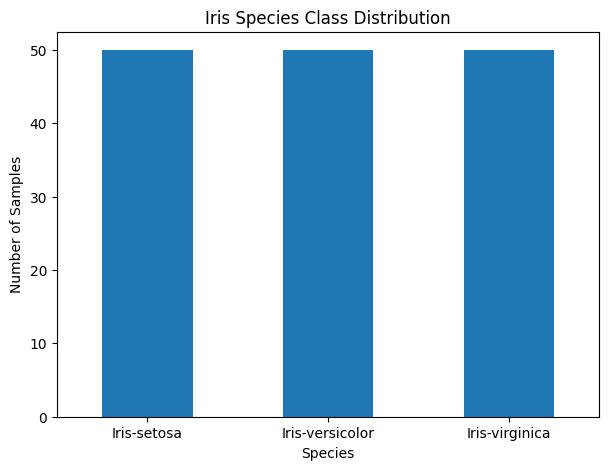

In [3]:
# Class Distribution

class_counts = df["Species"].value_counts()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")

plt.title("Iris Species Class Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [4]:
# Statistical Summary by Class

feature_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

summary = df.groupby("Species")[feature_columns].describe()

display(summary)

SepalLengthCm                                              \
                        count   mean       std  min    25%  50%  75%  max   
Species                                                                     
Iris-setosa              50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor          50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica           50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                SepalWidthCm         ... PetalLengthCm      PetalWidthCm  \
                       count   mean  ...           75%  max        count   
Species                              ...                                   
Iris-setosa             50.0  3.418  ...         1.575  1.9         50.0   
Iris-versicolor         50.0  2.770  ...         4.600  5.1         50.0   
Iris-virginica          50.0  2.974  ...         5.875  6.9         50.0   

                                                           
                  mean       std  min  25%  50%  75%  max  
Species                                                    
Iris-setosa      0.244  0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

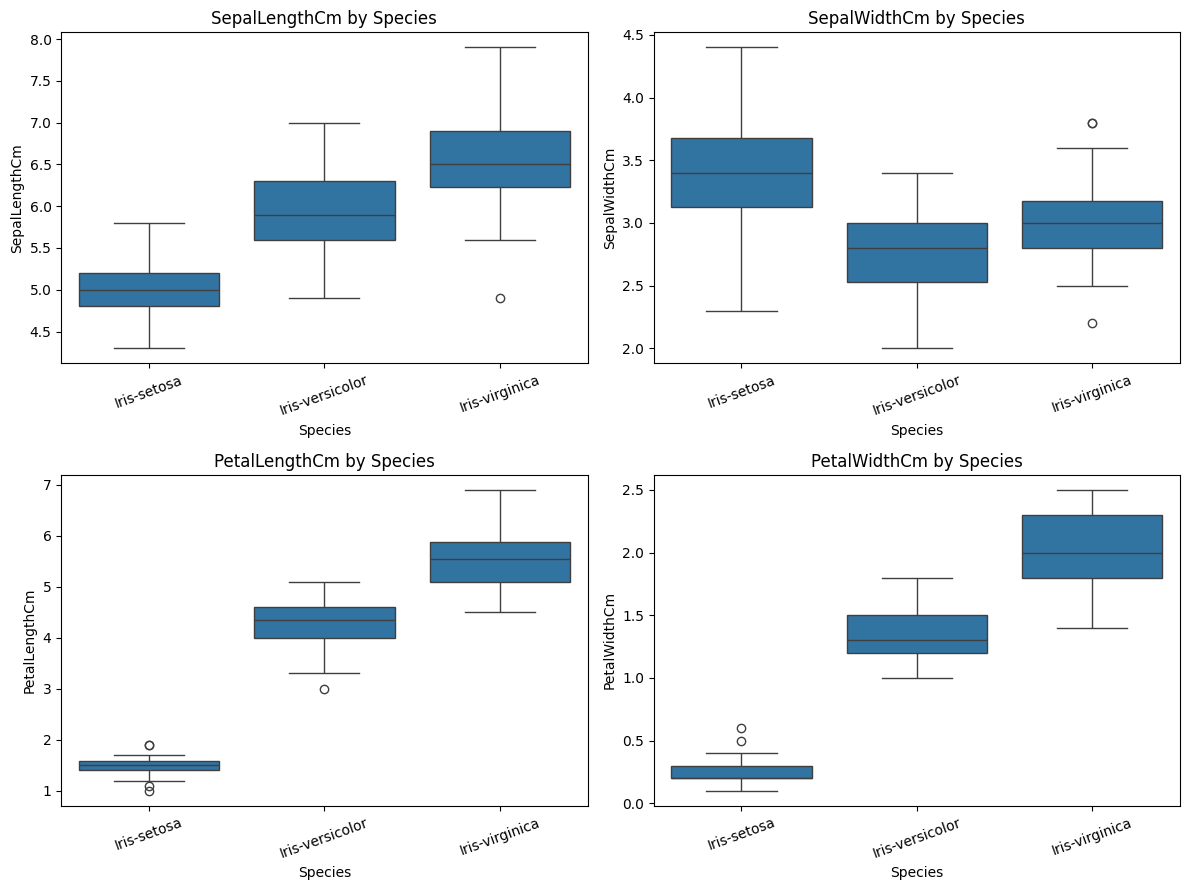

In [5]:
# Box Plots by Species

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feature, ax=ax)
    ax.set_title(f"{feature} by Species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

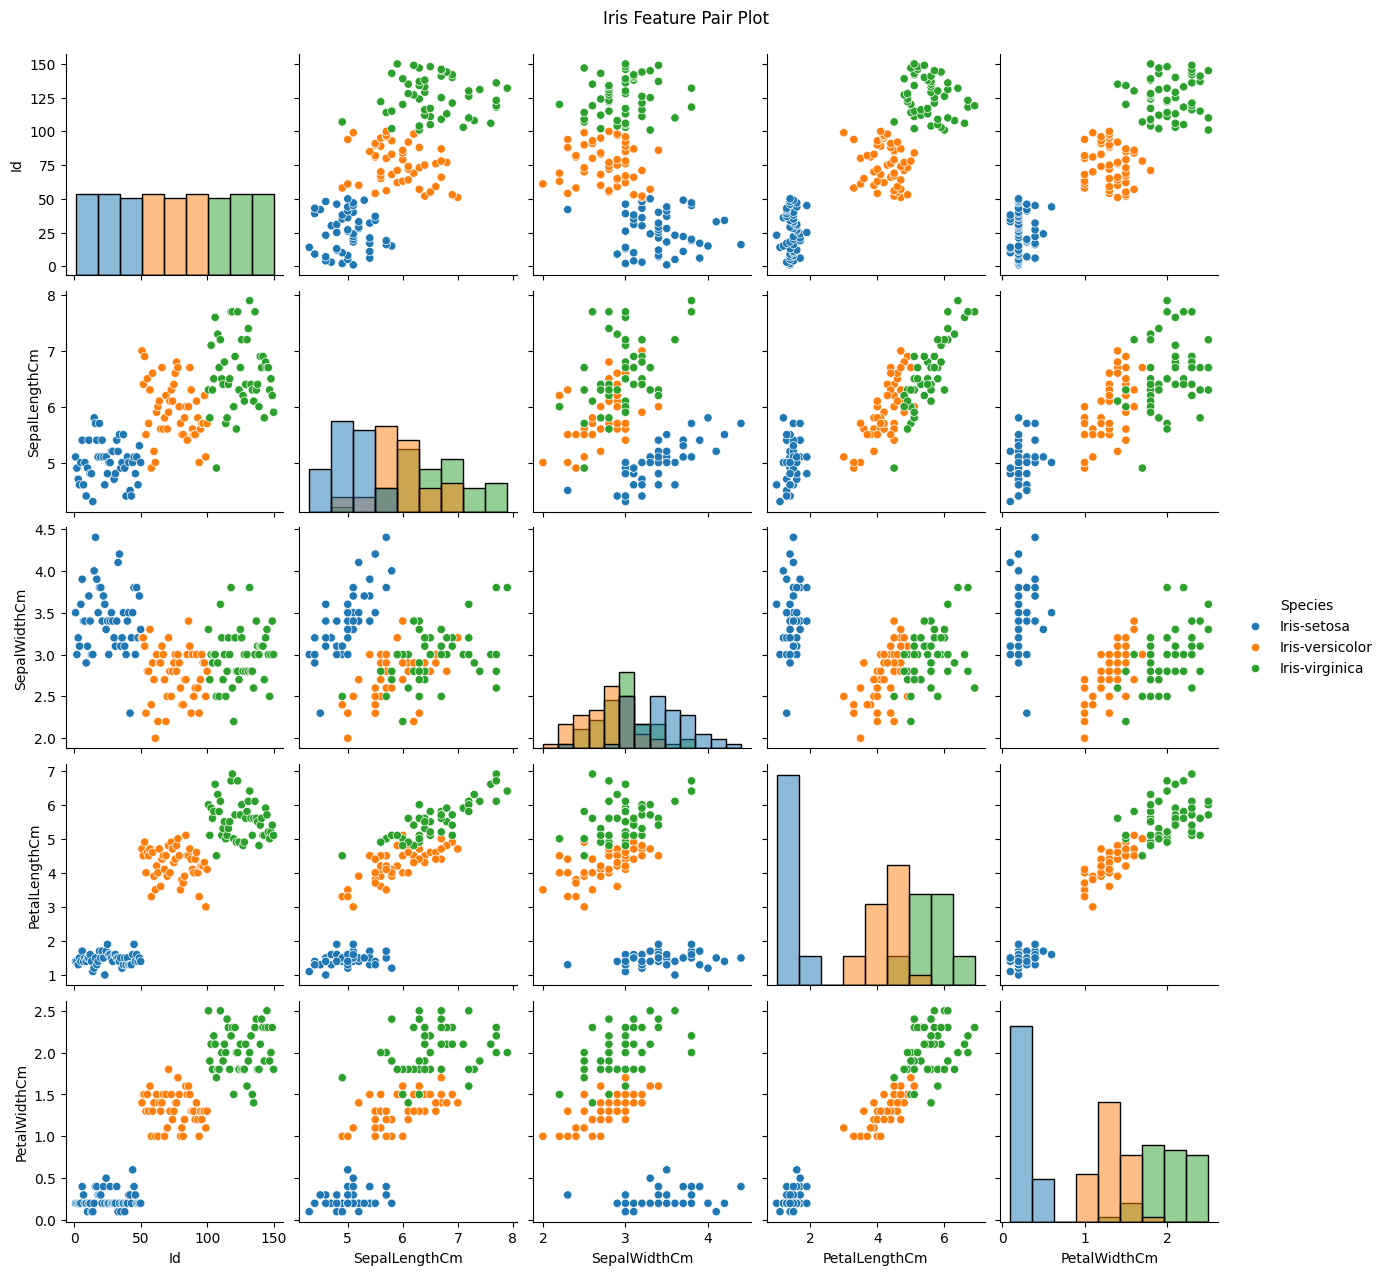

In [6]:
# Pair Plot

sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.suptitle("Iris Feature Pair Plot", y=1.02)
plt.show()


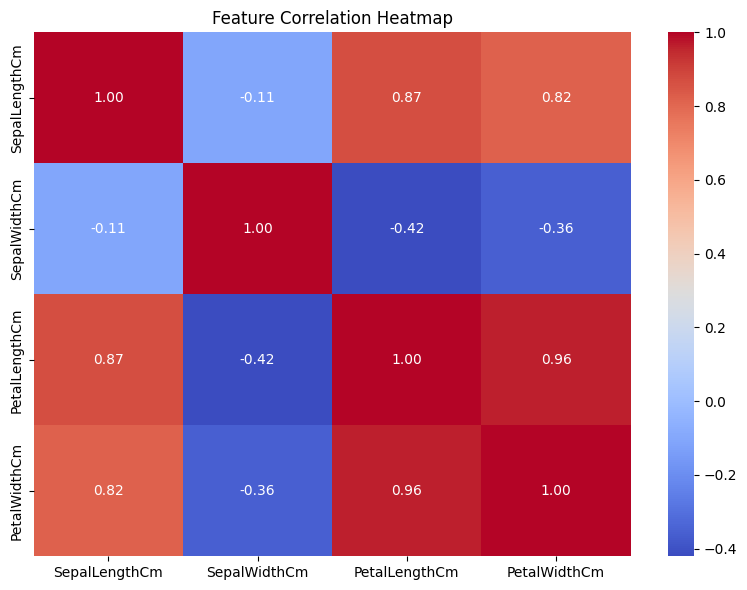

In [7]:
# Correlation Heatmap

correlation = df[feature_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## EDA Findings and Summary

The EDA shows that the Iris dataset is perfectly balanced, with 50 samples from each species and no missing values. Petal length and petal width are the strongest features for classification because Setosa is clearly separated from the other two species using petal features. Versicolor and Virginica overlap slightly in the petal feature space, so most classification errors are expected between these two classes. Sepal width is the weakest feature because it overlaps heavily across the three species. The correlation heatmap also shows that petal length and petal width are highly correlated (r ≈ 0.96), meaning they contain nearly redundant information. These findings suggest that models such as KNN, Decision Tree, and Logistic Regression should perform well, with petal features playing the most important role in classification.

In [8]:
# Step 11: Data Preprocessing

# Separate features and target
X = df.drop("Species", axis=1)
y = df["Species"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
print(label_encoder.classes_)

# Train-test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nScaled training data:")
print(X_train_scaled[:5])

Encoded classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Training set shape: (120, 5)
Testing set shape: (30, 5)

Scaled training data:
[[-1.55163971 -1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [ 0.72984103 -1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 0.03142856  1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.52835929 -1.12449223  0.12580502 -1.29021859 -1.45163753]
 [ 0.33407397 -0.40800161 -1.22612948  0.13020555  0.12599118]]


In [9]:
# Step 11: Data Preprocessing

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["Id", "Species"])
y = df["Species"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Preprocessing completed successfully.")

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Training set: (120, 4)
Testing set: (30, 4)
Preprocessing completed successfully.


In [10]:
# Step 12: K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


In [11]:
#Train KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


K = 3 | Accuracy = 0.9333
K = 5 | Accuracy = 0.9333
K = 7 | Accuracy = 0.9667
K = 9 | Accuracy = 0.9667
K = 11 | Accuracy = 0.9667


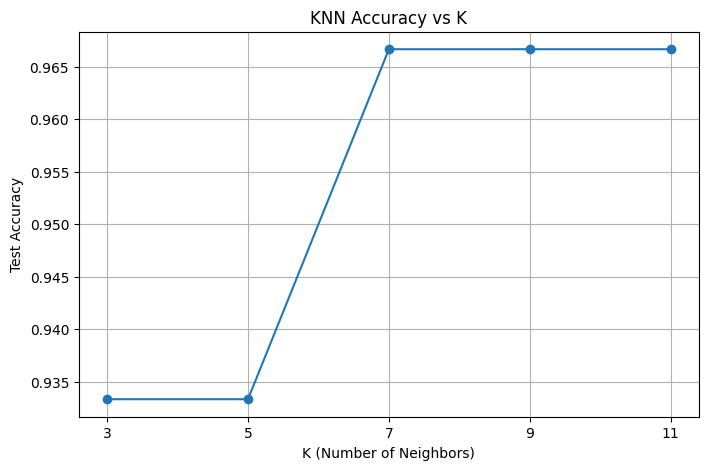

In [12]:
# KNN Hyperparameter Tuning

k_values = [3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    
    knn_results.append(accuracy)
    
    print(f"K = {k} | Accuracy = {accuracy:.4f}")

# Accuracy vs K plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_results, marker="o")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Decision Tree Model Training

A Decision Tree is a classification algorithm that learns decision rules by splitting the data based on feature values.

We will train a Decision Tree on the same training and testing split used for KNN. We will also tune the maximum tree depth to study the effect of model complexity and overfitting.

In [13]:
# Decision Tree Model Training

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Max Depth = 2 | Train Accuracy = 0.9667 | Test Accuracy = 0.9333
Max Depth = 3 | Train Accuracy = 0.9833 | Test Accuracy = 0.9667
Max Depth = 4 | Train Accuracy = 0.9917 | Test Accuracy = 0.9333
Max Depth = 5 | Train Accuracy = 1.0000 | Test Accuracy = 0.9333
Max Depth = None | Train Accuracy = 1.0000 | Test Accuracy = 0.9333


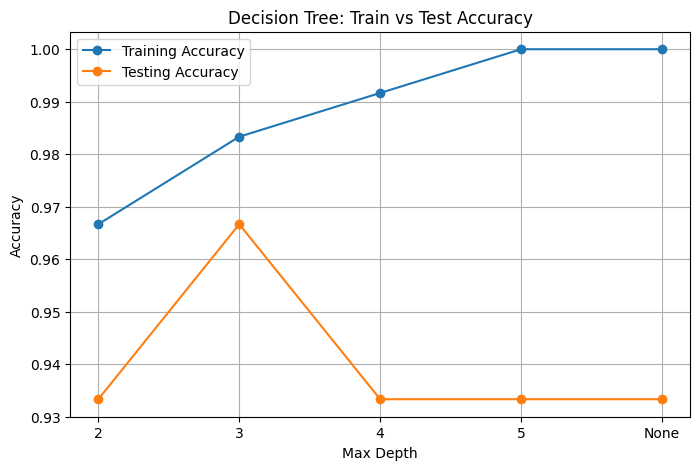

In [14]:
# Decision Tree Depth Tuning

depths = [2, 3, 4, 5, None]

train_accuracies = []
test_accuracies = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Max Depth = {depth} | Train Accuracy = {train_acc:.4f} | Test Accuracy = {test_acc:.4f}")

# Train vs Test Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(range(len(depths)), train_accuracies, marker="o", label="Training Accuracy")
plt.plot(range(len(depths)), test_accuracies, marker="o", label="Testing Accuracy")

plt.xticks(range(len(depths)), ["2", "3", "4", "5", "None"])
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=200
)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5-Fold Cross-Validation

5-fold cross-validation is used to evaluate the consistency and reliability of the three machine learning models.

We will calculate the mean accuracy and standard deviation for KNN, Decision Tree, and Logistic Regression.

In [16]:
# 5-Fold Cross-Validation

from sklearn.model_selection import cross_val_score
import numpy as np

# KNN
knn_cv = cross_val_score(knn, X_train_scaled, y_train, cv=5)

# Decision Tree
dt_cv = cross_val_score(dt, X_train, y_train, cv=5)

# Logistic Regression
log_cv = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)

print("KNN:")
print("Mean Accuracy:", knn_cv.mean())
print("Standard Deviation:", knn_cv.std())

print("\nDecision Tree:")
print("Mean Accuracy:", dt_cv.mean())
print("Standard Deviation:", dt_cv.std())

print("\nLogistic Regression:")
print("Mean Accuracy:", log_cv.mean())
print("Standard Deviation:", log_cv.std())

KNN:
Mean Accuracy: 0.9666666666666668
Standard Deviation: 0.031180478223116186

Decision Tree:
Mean Accuracy: 0.9333333333333333
Standard Deviation: 0.020412414523193187

Logistic Regression:
Mean Accuracy: 0.9583333333333334
Standard Deviation: 0.026352313834736508


## Model Comparison

The performance of KNN, Decision Tree, and Logistic Regression is compared using their test accuracy and cross-validation results.

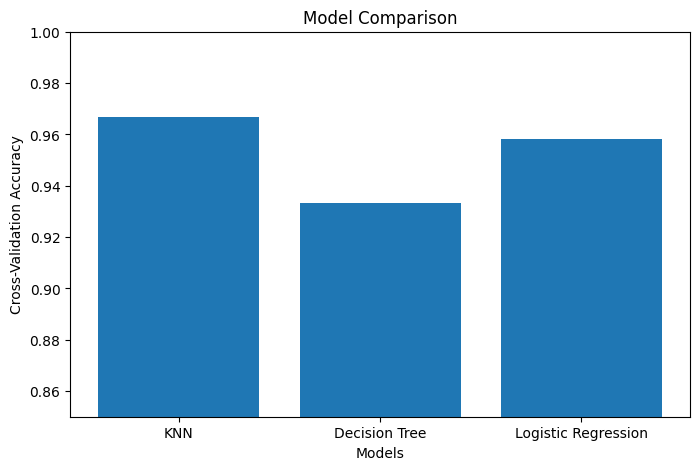

In [17]:
# Model Comparison

models = ['KNN', 'Decision Tree', 'Logistic Regression']
accuracies = [
    knn_cv.mean(),
    dt_cv.mean(),
    log_cv.mean()
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Model Comparison')
plt.ylim(0.85, 1.0)
plt.show()

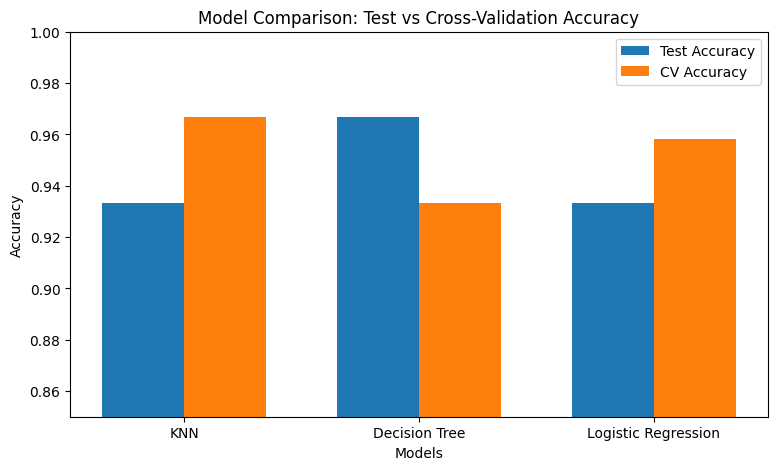

In [18]:
# Model Comparison: Test Accuracy vs Cross-Validation Accuracy

from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

models = ['KNN', 'Decision Tree', 'Logistic Regression']

test_accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_log)
]

cv_accuracies = [
    knn_cv.mean(),
    dt_cv.mean(),
    log_cv.mean()
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, test_accuracies, width, label='Test Accuracy')
plt.bar(x + width/2, cv_accuracies, width, label='CV Accuracy')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Test vs Cross-Validation Accuracy')
plt.xticks(x, models)
plt.ylim(0.85, 1.0)
plt.legend()
plt.show()

# Conclusions

## Model Performance
The three machine learning models performed well on the Iris dataset. 
KNN achieved the highest cross-validation accuracy of approximately 96.67%, 
followed by Logistic Regression with approximately 95.83%. 
Decision Tree achieved approximately 93.33% cross-validation accuracy.

## Key Findings
Petal length and petal width were the most important features for classification. 
The Iris-Setosa class was clearly separated from the other two species, while 
some overlap existed between Iris-Versicolor and Iris-Virginica.

## Model Selection
KNN is the preferred model because it achieved the highest cross-validation 
accuracy and performed consistently well on the dataset. 
Decision Tree is the most interpretable model because its decision rules are 
easy to understand and visualize.

## Limitations
The dataset contains only 150 samples, so the results may not generalize to 
larger or more diverse datasets. Cross-validation was used to obtain a more 
reliable estimate of model performance.

## Final Conclusion
Overall, all three models performed well on the Iris classification task. 
KNN provided the best overall cross-validation performance, while Decision 
Tree offered better interpretability. Therefore, KNN would be selected for 
deployment based on its cross-validation performance.